
# 01 — Data Collection & Class Balancing

## Objective
This notebook handles the first stage of the sentiment analysis pipeline for the e-commerce AI integration project.

## Steps Covered
1. **Data Loading** — Import the labeled customer comments dataset
2. **Exploratory Analysis** — Inspect class distribution (Positive / Neutral / Negative)
3. **Class Imbalance Handling** — Address the imbalanced distribution (94% Positive / 4% Neutral / 2% Negative) using resampling

## Context
The raw dataset suffers from severe class imbalance. Without correction, fine-tuning RoBERTa on this data would produce a model biased toward positive sentiment, reducing its ability to detect critical neutral and negative customer feedback.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load & Extract Dataset

In [18]:
import zipfile
import pandas as pd
from matplotlib import pyplot as plt
import os

In [5]:
zip_file_path = "/content/drive/MyDrive/transformers/Ecommerce/CustomerFeedbackAnalysis/ProductsReviews.zip"
working_directory = "/content/drive/MyDrive/transformers/Ecommerce/CustomerFeedbackAnalysis"

In [6]:
with zipfile.ZipFile(zip_file_path) as zip_file:
  zip_file.extractall(working_directory)

In [7]:
csv_file_path = os.path.join(working_directory, "ProductsReviews.csv")

In [8]:
data_frame = pd.read_csv(csv_file_path)

In [10]:
data_frame.head()

,name,brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Purchased on Black FridayPros - Great Price (e...,Powerful tablet,Positive
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two do...,Amazon Echo Plus AWESOME,Positive
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few ...,Average,Neutral
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and ...",Greattttttt,Positive
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bough...,Very durable!,Positive


In [11]:
df = data_frame[["reviews.text","sentiment"]]

In [12]:
df.head()

,reviews.text,sentiment
0,Purchased on Black FridayPros - Great Price (e...,Positive
1,I purchased two Amazon in Echo Plus and two do...,Positive
2,Just an average Alexa option. Does show a few ...,Neutral
3,"very good product. Exactly what I wanted, and ...",Positive
4,This is the 3rd one I've purchased. I've bough...,Positive


## 2. Exploratory Data Analysis (EDA)

In [14]:
df.shape

(4000, 2)

In [63]:
working_directory = "/content/drive/MyDrive/transformers/Ecommerce/CustomerFeedbackAnalysis/images"

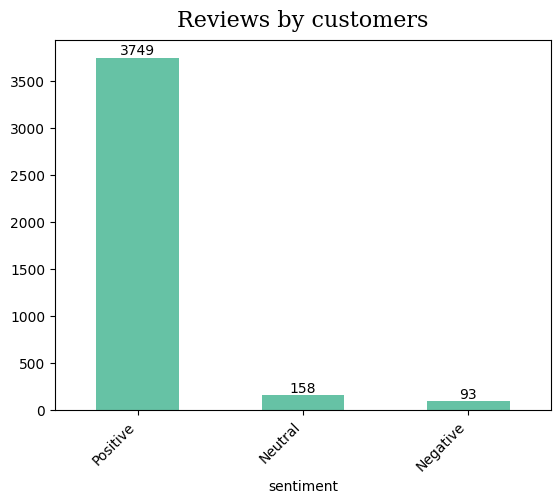

In [64]:
ax = df["sentiment"].value_counts().plot(kind="bar", cmap="Set2")

plt.xticks(rotation = 45, ha="right")

for container in ax.containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        value,
        ha="center",
        va="bottom"
      )

plt.title("Reviews by customers", fontsize=16, fontfamily="serif", pad=10)
plt.savefig(os.path.join(working_directory, "sentiment_class_distribution_chart.png"), dpi=300, bbox_inches="tight")
plt.show()


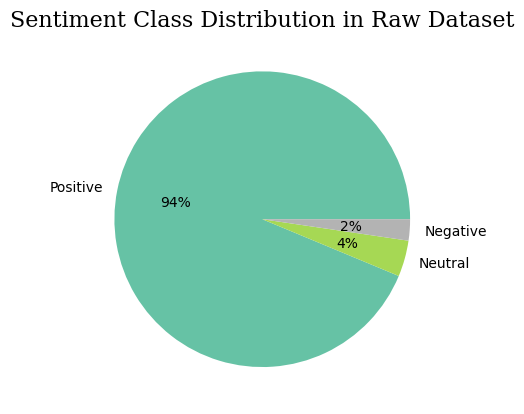

In [65]:
df["sentiment"].value_counts().plot(kind="pie", startangle=0, autopct="%1.0f%%", cmap="Set2")
plt.title("Sentiment Class Distribution in Raw Dataset", fontsize=16, fontfamily="serif")
plt.ylabel("")
plt.savefig(os.path.join(working_directory, "sentiment_class_distribution_pie.png"), dpi=300, bbox_inches="tight")
plt.show()

## 3. Class Imbalance Handling

In [66]:
df["sentiment"].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

In [68]:
def map_sentiment_to_class(sentiment):
  if sentiment == "Positive":
    return 2
  if sentiment =="Neutral" :
    return 1
  return 0

In [72]:
df["class"]  = df["sentiment"].apply(map_sentiment_to_class).copy()

/tmp/ipykernel_4075/1770122685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["class"]  = df["sentiment"].apply(map_sentiment_to_class).copy()


In [73]:
df.head()

,reviews.text,sentiment,class
0,Purchased on Black FridayPros - Great Price (e...,Positive,2
1,I purchased two Amazon in Echo Plus and two do...,Positive,2
2,Just an average Alexa option. Does show a few ...,Neutral,1
3,"very good product. Exactly what I wanted, and ...",Positive,2
4,This is the 3rd one I've purchased. I've bough...,Positive,2


In [77]:
sentiment_classes = df["sentiment"].unique().tolist()

In [78]:
sentiment_classes

['Positive', 'Neutral', 'Negative']

In [81]:
total_rows = 300

class_rows = int(total_rows/3)

df_balanced = pd.DataFrame()
for sentiment in sentiment_classes:
  df_temp = df[df["sentiment"] == sentiment].sample(n=min(class_rows, len(df[df["sentiment"] == sentiment])), random_state=42)
  df_balanced= pd.concat([df_balanced, df_temp],)

df_balanced = df_balanced.reset_index(drop=True)

df_balanced



,reviews.text,sentiment,class
0,Delivered on time and it looked good will hook...,Positive,2
1,The price for this tablet is not the only grea...,Positive,2
2,Perfect item for any place in your house. Love...,Positive,2
3,My husband loves this Kindle. He has a muscula...,Positive,2
4,The Amazon Kindle is a series of e-readers des...,Positive,2
...,...,...,...
288,I bought a Kindle Fire 16GB for my 6 year old ...,Negative,0
289,This is not an upgrade by any means! My three ...,Negative,0
290,So slow returning mine for something different...,Negative,0
291,Not a very responsive program. Very limited in...,Negative,0


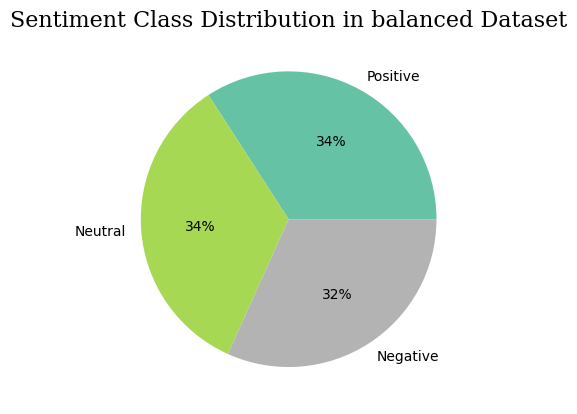

In [82]:
df_balanced["sentiment"].value_counts().plot(kind="pie", startangle=0, autopct="%1.0f%%", cmap="Set2")
plt.title("Sentiment Class Distribution in balanced Dataset", fontsize=16, fontfamily="serif")
plt.ylabel("")
plt.savefig(os.path.join(working_directory, "balanced_sentiment_class_distribution_pie.png"), dpi=300, bbox_inches="tight")
plt.show()

In [84]:
df_balanced.to_csv("/content/drive/MyDrive/transformers/Ecommerce/CustomerFeedbackAnalysis/balanced_dataset.csv", index=False)